# Niv-integrated sky decomposition

This notebook is the inspectable output for the merged decomposition work. It checks the downloaded Niv reference products, compares the legacy and integrated methods on one held-out native-grid spectrum, records the new PCA30 basis trained on 1,000 spectra, summarizes the full-stack Adam decomposition, and evaluates the retrained Niv MLP variant.

Scientific contract: all fits use the exact 12,401-pixel input wavelength grid. No wavelength pixel is resampled, binned, smoothed, cropped, removed, or replaced. Science-line windows are excluded only by setting inverse variance to zero during fitting.


In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from astropy.io import fits
from IPython.display import Markdown, display

REPO = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "skysub" / "sky_decomp").is_dir()
)
sys.path.insert(0, str(REPO / "skysub"))
sys.path.insert(0, str(REPO))

from skysub import decompose_parallel as decompose
from skysub.sky_decomp.moon_zodi_model import file_sha256
from skysub.sky_decomp.result_io import load_lsf_surface_state

EXPERIMENT = REPO / "skysub" / "experiments_niv_integrated_decomposition_v1"
OBS_ROOT = Path("/Users/ik52/obs/sas/sdsswork/users/u6058164")
REFERENCE_ROOT = OBS_ROOT / "moon_zodi_spline"
FULL_STACK = OBS_ROOT / "lvmsframe_median_stack_1.2.1_gaia1over100.fits"
EVERY10 = REFERENCE_ROOT / "lvmsframe_median_stack_1.2.1_gaia1over100_every10.fits"
FULL_OUTPUT = EXPERIMENT / "outputs" / "full_adam"
SAMPLE_ROW = 773
FULL_SOURCE_ROW = SAMPLE_ROW * 10
SCALE = 1.0e14

assert FULL_STACK.is_file() and EVERY10.is_file()
assert (REPO / "skysub" / "sky_decomp" / "data").is_dir()
print(f"Repository: {REPO}")
print(f"Full stack: {FULL_STACK}")


Repository: /Users/ik52/sci/work/nyuad-galaxies/sdss5/sky_subtract/lvmsky
Full stack: /Users/ik52/obs/sas/sdsswork/users/u6058164/lvmsframe_median_stack_1.2.1_gaia1over100.fits


## Downloaded Niv reference products

The reference files are an external reproduction target, not the final production contract. They were generated before Niv's last change of the moon-gated diffuse/OH upper width from 0.30 dex back to 0.15 dex, and they store a channel-median legacy LSF rather than the continuous reconstructed surface retained by the integrated methods.


In [2]:
expected_sha256 = {
    "source": "df0eaab697a63a87d157ffea0353ea2fc8c21ed02c575987aeec967c9de81fd7",
    "sci": "0d8f3dd6691fb82d12fe17c9c0c826fc06cd8640e6871db79a61de659bcd8bfa",
    "sky1": "7055b9c3c856d61a8dc7471b46670acdaad6b15bddc97a02ed1944412c722027",
    "sky2": "71313f085c7ee45361396698f49231a31cfc3a7abe869fd57efc07c3e9a84765",
}
reference_paths = {
    "source": EVERY10,
    "sci": REFERENCE_ROOT / "lvmsframe_median_stack_1.2.1_gaia1over100_every10_decomp_sci_lsf_surface_iterative_split_zodi.fits",
    "sky1": REFERENCE_ROOT / "lvmsframe_median_stack_1.2.1_gaia1over100_every10_decomp_sky1_lsf_surface_iterative_split_zodi.fits",
    "sky2": REFERENCE_ROOT / "lvmsframe_median_stack_1.2.1_gaia1over100_every10_decomp_sky2_lsf_surface_iterative_split_zodi.fits",
}
checksum_rows = []
for role, path in reference_paths.items():
    actual = file_sha256(path)
    checksum_rows.append({
        "role": role,
        "file": path.name,
        "size_GiB": path.stat().st_size / 2**30,
        "sha256": actual,
        "matches_transfer": actual == expected_sha256[role],
    })
checksum_table = pd.DataFrame(checksum_rows)
assert checksum_table["matches_transfer"].all()
checksum_table


,role,file,size_GiB,sha256,matches_transfer
0,source,lvmsframe_median_stack_1.2.1_gaia1over100_ever...,0.470172,df0eaab697a63a87d157ffea0353ea2fc8c21ed02c5759...,True
1,sci,lvmsframe_median_stack_1.2.1_gaia1over100_ever...,2.023104,0d8f3dd6691fb82d12fe17c9c0c826fc06cd8640e6871d...,True
2,sky1,lvmsframe_median_stack_1.2.1_gaia1over100_ever...,2.022933,7055b9c3c856d61a8dc7471b46670acdaad6b15bddc97a...,True
3,sky2,lvmsframe_median_stack_1.2.1_gaia1over100_ever...,2.023102,71313f085c7ee45361396698f49231a31cfc3a7abe869f...,True


In [3]:
with fits.open(FULL_STACK, memmap=True) as full_hdul, fits.open(EVERY10, memmap=True) as thin_hdul:
    wave = np.asarray(full_hdul["WAVE"].data, dtype=np.float64).copy()
    thin_wave = np.asarray(thin_hdul["WAVE"].data, dtype=np.float64)
    sample_flux = np.asarray(thin_hdul["FLUX_SCI"].data[SAMPLE_ROW], dtype=np.float64) * SCALE
    np.testing.assert_array_equal(wave, thin_wave)
    np.testing.assert_array_equal(
        thin_hdul["FLUX_SCI"].data[SAMPLE_ROW],
        full_hdul["FLUX_SCI"].data[FULL_SOURCE_ROW],
    )

reference_status = []
for role in ("sci", "sky1", "sky2"):
    with fits.open(reference_paths[role], memmap=True) as hdul:
        status = np.char.strip(hdul["META"].data["fit_status"].astype(str))
        reference_status.append({
            "role": role,
            "rows": len(status),
            "solved": int(np.isin(status, ("Solved", "AlmostSolved")).sum()),
            "failed": int((~np.isin(status, ("Solved", "AlmostSolved"))).sum()),
            "coefficients": len(hdul["COEF"].columns),
            "lsf_shape": str(hdul["LSF_COEF"].data.shape),
        })
assert wave.size == 12_401
pd.DataFrame(reference_status)


,role,rows,solved,failed,coefficients,lsf_shape
0,sci,1447,1445,2,388,"(1447, 3, 11, 6)"
1,sky1,1447,1445,2,388,"(1447, 3, 11, 6)"
2,sky2,1447,1446,1,388,"(1447, 3, 11, 6)"


## Methods retained after the merge

The old public classes remain available. Two new named classes freeze Niv's continuum choices so later default changes cannot silently alter the integrated methods. The Adam variant has no PCA correction; the PALACE-Aijc VNF variant appends one signed mean direction and 30 signed PCA scores. Both retain the per-spectrum continuous B/R/Z LSF surface.


In [4]:
method_table = pd.DataFrame([
    {
        "label": "Downloaded Niv reference",
        "fit_model": "lsf-surface-iterative-split-zodi",
        "line_model": "Niv branch default OH",
        "continuum": "Niv split Moon/Zodi + diffuse priors",
        "PCA30": False,
        "LSF": "legacy channel median in reference file",
    },
    {
        "label": "Legacy Adam25k",
        "fit_model": "adam25k-telluric-lsf-spline2d",
        "line_model": "telluric-aware Adam25k OH",
        "continuum": "legacy unsplit continuum",
        "PCA30": False,
        "LSF": "continuous M-spline surface",
    },
    {
        "label": "Legacy PALACE VNF + PCA30",
        "fit_model": "palace-aijc-vnf-line-amplitude-pca30",
        "line_model": "PALACE Aijc VNF",
        "continuum": "legacy unsplit continuum",
        "PCA30": True,
        "LSF": "continuous M-spline surface",
    },
    {
        "label": "Integrated Adam25k + Niv",
        "fit_model": "adam25k-telluric-niv-continuum",
        "line_model": "telluric-aware Adam25k OH",
        "continuum": "frozen Niv v1 contract",
        "PCA30": False,
        "LSF": "continuous M-spline surface",
    },
    {
        "label": "Integrated PALACE VNF + Niv + PCA30",
        "fit_model": "palace-aijc-vnf-pca30-niv-continuum",
        "line_model": "PALACE Aijc VNF",
        "continuum": "frozen Niv v1 contract",
        "PCA30": True,
        "LSF": "continuous M-spline surface",
    },
])
method_table


,label,fit_model,line_model,continuum,PCA30,LSF
0,Downloaded Niv reference,lsf-surface-iterative-split-zodi,Niv branch default OH,Niv split Moon/Zodi + diffuse priors,False,legacy channel median in reference file
1,Legacy Adam25k,adam25k-telluric-lsf-spline2d,telluric-aware Adam25k OH,legacy unsplit continuum,False,continuous M-spline surface
2,Legacy PALACE VNF + PCA30,palace-aijc-vnf-line-amplitude-pca30,PALACE Aijc VNF,legacy unsplit continuum,True,continuous M-spline surface
3,Integrated Adam25k + Niv,adam25k-telluric-niv-continuum,telluric-aware Adam25k OH,frozen Niv v1 contract,False,continuous M-spline surface
4,Integrated PALACE VNF + Niv + PCA30,palace-aijc-vnf-pca30-niv-continuum,PALACE Aijc VNF,frozen Niv v1 contract,True,continuous M-spline surface


## Held-out native-grid comparison

Row 773 of the every-10 file is full-stack source row 7,730 and is not part of the 1,000-spectrum PCA training selection. The downloaded reference did not use the final science-line mask or final 0.15-dex diffuse/OH contract, so its residual metric is shown as a reproduction check rather than an apples-to-apples ranking.


In [5]:
fit_models = {
    "Legacy Adam25k": decompose.ADAM25K_TELLURIC_FIT_MODEL,
    "Legacy PALACE VNF + PCA30": decompose.PALACE_VNF_PCA30_FIT_MODEL,
    "Integrated Adam25k + Niv": decompose.ADAM25K_NIV_CONTINUUM_FIT_MODEL,
    "Integrated PALACE VNF + Niv + PCA30": decompose.PALACE_VNF_PCA30_NIV_CONTINUUM_FIT_MODEL,
}
fitted = {}
for label, fit_model in fit_models.items():
    if decompose._WORKER_HDU is not None:
        decompose._WORKER_HDU.close()
    decompose.init_worker(
        wave,
        0.5,
        str(REPO / "skysub" / "sky_decomp" / "data"),
        SCALE,
        str(EVERY10),
        fit_model=fit_model,
        n_refinement_cycles=5,
        n_spline_knots=11,
        n_zodi_spline_knots=1,
        zodi_smooth_lambda=0.1,
    )
    flux = np.asarray(decompose._WORKER_FLUX["sci"][SAMPLE_ROW], dtype=np.float64) * SCALE
    fitted[label] = decompose._fit_worker_row(
        "sci", SAMPLE_ROW, flux, np.ones_like(flux)
    )

with fits.open(reference_paths["sci"], memmap=True) as ref_hdul:
    reference_bestfit = np.asarray(
        ref_hdul["BESTFIT_LSF"].data[SAMPLE_ROW], dtype=np.float64
    ).copy()
    reference_meta = ref_hdul["META"].data[SAMPLE_ROW]
    reference_coef_count = len(ref_hdul["COEF"].columns)

metrics = [{
    "method": "Downloaded Niv reference",
    "fit_status": decompose._text_value(reference_meta["fit_status"]),
    "coefficients": reference_coef_count,
    "rms_resid": float(reference_meta["rms_resid"]),
    "r2": float(reference_meta["r2"]),
    "lsf_cycles": int(fits.getdata(reference_paths["sci"], "LSF_META")[3 * SAMPLE_ROW]["completed_cycles"]),
    "lsf_representation": "native_grid_channel_median",
}]
for label, result in fitted.items():
    metrics.append({
        "method": label,
        "fit_status": result.fit_status,
        "coefficients": len(result.coef),
        "rms_resid": result.rms_resid,
        "r2": result.r2,
        "lsf_cycles": result.lsf_state.completed_cycles,
        "lsf_representation": result.lsf_state.legacy_kernel_representation,
    })
metrics = pd.DataFrame(metrics)
metrics


[INFO]: Loading telluric transmission model from '/Users/ik52/obs/sas/sdsswork/lvm/sandbox/calib/stellar_models/lvm-model_transmission_Palace_SkyModel_step0.2-all.fits'


[science-line mask] 85/12401 pixels (0.69%) excluded via IVAR=0 in 10 windows: [OII]3726 +/-2.4A, [OII]3729 +/-2.4A, Hbeta +/-2.4A, [OIII]4959 +/-2.4A, [OIII]5007 +/-2.4A, [NII]6548 +/-2.0A, Halpha +/-2.0A, [NII]6583 +/-2.0A, [SII]6716 +/-2.0A, [SII]6731 +/-2.0A; centred per row on the measured Halpha velocity


[INFO]: Loading telluric transmission model from '/Users/ik52/obs/sas/sdsswork/lvm/sandbox/calib/stellar_models/lvm-model_transmission_Palace_SkyModel_step0.2-all.fits'


[science-line mask] 85/12401 pixels (0.69%) excluded via IVAR=0 in 10 windows: [OII]3726 +/-2.4A, [OII]3729 +/-2.4A, Hbeta +/-2.4A, [OIII]4959 +/-2.4A, [OIII]5007 +/-2.4A, [NII]6548 +/-2.0A, Halpha +/-2.0A, [NII]6583 +/-2.0A, [SII]6716 +/-2.0A, [SII]6731 +/-2.0A; centred per row on the measured Halpha velocity


[INFO]: Loading telluric transmission model from '/Users/ik52/obs/sas/sdsswork/lvm/sandbox/calib/stellar_models/lvm-model_transmission_Palace_SkyModel_step0.2-all.fits'


[science-line mask] 85/12401 pixels (0.69%) excluded via IVAR=0 in 10 windows: [OII]3726 +/-2.4A, [OII]3729 +/-2.4A, Hbeta +/-2.4A, [OIII]4959 +/-2.4A, [OIII]5007 +/-2.4A, [NII]6548 +/-2.0A, Halpha +/-2.0A, [NII]6583 +/-2.0A, [SII]6716 +/-2.0A, [SII]6731 +/-2.0A; centred per row on the measured Halpha velocity


[INFO]: Loading telluric transmission model from '/Users/ik52/obs/sas/sdsswork/lvm/sandbox/calib/stellar_models/lvm-model_transmission_Palace_SkyModel_step0.2-all.fits'


[science-line mask] 85/12401 pixels (0.69%) excluded via IVAR=0 in 10 windows: [OII]3726 +/-2.4A, [OII]3729 +/-2.4A, Hbeta +/-2.4A, [OIII]4959 +/-2.4A, [OIII]5007 +/-2.4A, [NII]6548 +/-2.0A, Halpha +/-2.0A, [NII]6583 +/-2.0A, [SII]6716 +/-2.0A, [SII]6731 +/-2.0A; centred per row on the measured Halpha velocity


,method,fit_status,coefficients,rms_resid,r2,lsf_cycles,lsf_representation
0,Downloaded Niv reference,Solved,388,0.395049,0.991008,5,native_grid_channel_median
1,Legacy Adam25k,Solved,390,0.355303,0.992727,5,continuous_mspline_density
2,Legacy PALACE VNF + PCA30,Solved,421,0.324577,0.993930,5,continuous_mspline_density
3,Integrated Adam25k + Niv,Solved,388,0.355694,0.992711,5,continuous_mspline_density
4,Integrated PALACE VNF + Niv + PCA30,Solved,419,0.348057,0.993020,5,continuous_mspline_density


In [6]:
bestfits = {"Downloaded Niv reference": reference_bestfit}
bestfits.update({label: result.bestfit_lsf for label, result in fitted.items()})
figure = go.Figure()
figure.add_trace(go.Scattergl(
    x=wave, y=sample_flux, name="Observed SCI", line={"color": "#202020", "width": 1}
))
colours = ["#6a3d9a", "#1f78b4", "#33a02c", "#ff7f00", "#e31a1c"]
for (label, values), colour in zip(bestfits.items(), colours):
    figure.add_trace(go.Scattergl(
        x=wave, y=values, name=label, line={"color": colour, "width": 1}
    ))
figure.update_layout(
    title=f"Held-out SCI spectrum: every10 row {SAMPLE_ROW} / full row {FULL_SOURCE_ROW}",
    xaxis_title="Vacuum wavelength [Angstrom]",
    yaxis_title="Scaled flux [input flux x 1e14]",
    template="plotly_white",
    height=560,
    legend={"orientation": "h", "y": -0.22},
)
figure.show()


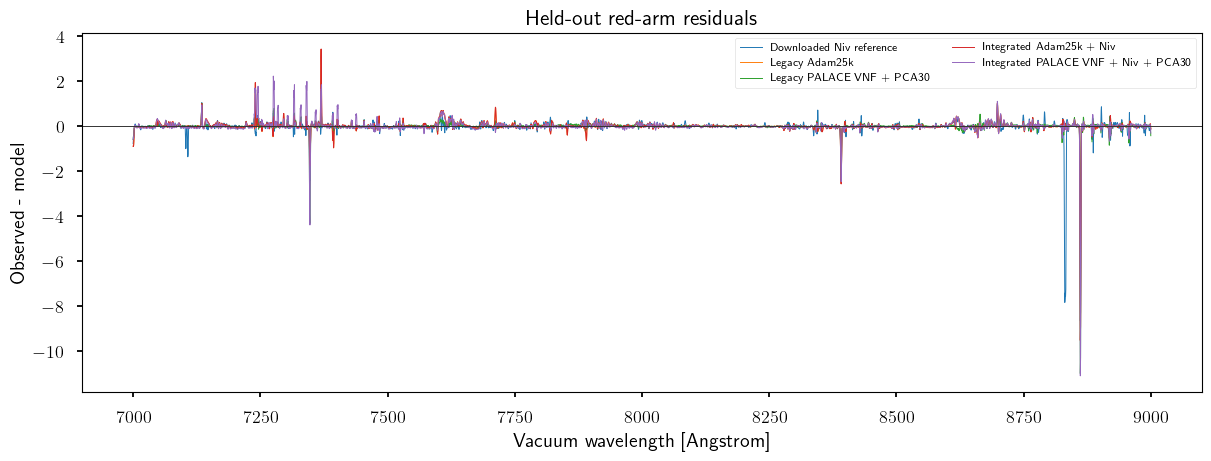

In [7]:
window = (wave >= 7000.0) & (wave <= 9000.0)
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
for label, values in bestfits.items():
    ax.plot(wave[window], (sample_flux - values)[window], lw=0.7, label=label)
ax.axhline(0.0, color="0.2", lw=0.7)
ax.set(
    xlabel="Vacuum wavelength [Angstrom]",
    ylabel="Observed - model",
    title="Held-out red-arm residuals",
)
ax.legend(ncol=2, fontsize=8)
plt.show()


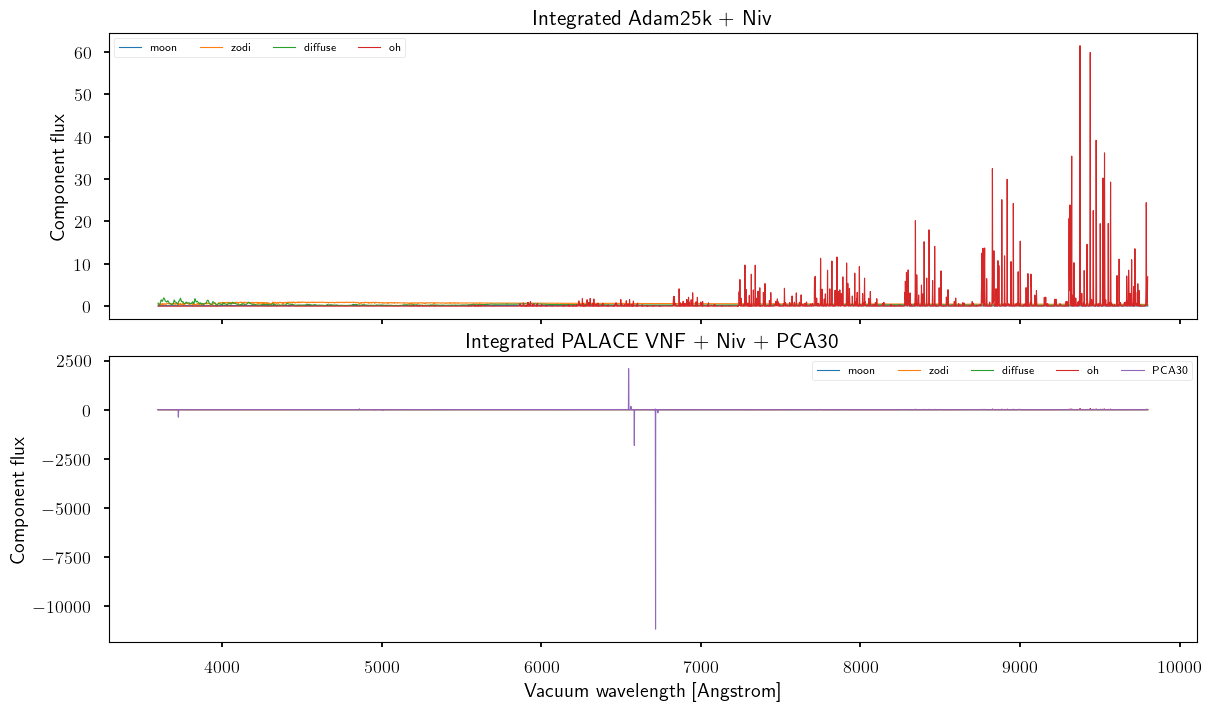

In [8]:
integrated_labels = (
    "Integrated Adam25k + Niv",
    "Integrated PALACE VNF + Niv + PCA30",
)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
for ax, label in zip(axes, integrated_labels):
    components = fitted[label].components
    for name in ("moon", "zodi", "diffuse", "oh"):
        ax.plot(wave, components[name], lw=0.8, label=name)
    if "line_amplitude_pca" in components:
        ax.plot(wave, components["line_amplitude_pca"], lw=0.8, label="PCA30")
    ax.set(title=label, ylabel="Component flux")
    ax.legend(ncol=5, fontsize=8)
axes[-1].set_xlabel("Vacuum wavelength [Angstrom]")
plt.show()


## Recalculated PCA30 on 1,000 spectra

The PCA coordinates are trained from signed, weakly ridge-regularized amplitudes of all 11,552 individual line transitions in the residual of the integrated PALACE-Aijc VNF + Niv-continuum fit. Each line profile uses that spectrum's telluric transmission and recovered continuous LSF surface. PCA preprocessing is column-mean subtraction only.


input spectra                                                                  1000
successful fits                                                                1000
training spectra after RMS cut                                                  983
native pixels                                                                 12401
line amplitudes                                                               11552
stored PCs                                                                       30
variance explained by PCA30                                                0.999726
asset SHA256                      b2a1253fb50f78603cd18c16143a2060d4a6ddd2ae6141...
dtype: object

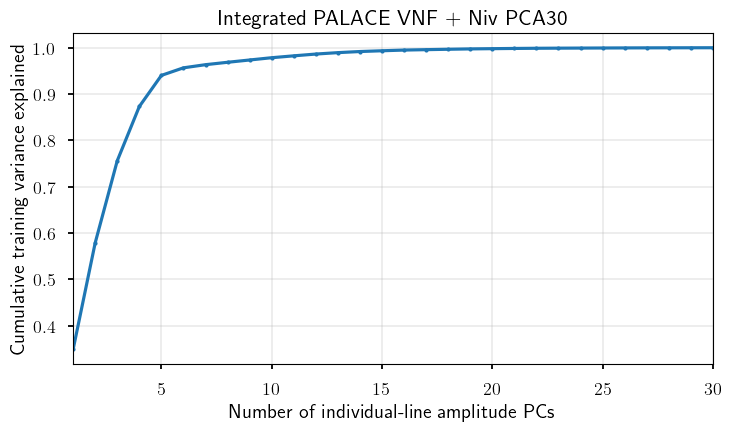

In [9]:
pca_summary_path = EXPERIMENT / "outputs" / "pca30" / "pca_asset_summary.json"
pca_asset = REPO / "skysub" / "sky_decomp" / "data" / "residual_pca" / "palace_aijc_vnf_niv_continuum_line_amplitude_pca_v1.npz"
pca_summary = json.loads(pca_summary_path.read_text())
with np.load(pca_asset, allow_pickle=False) as asset:
    explained = np.asarray(asset["explained_variance_ratio"], dtype=np.float64)
    pca_metadata = json.loads(str(asset["metadata_json"].item()))
    assert asset["components"].shape == (30, 11_552)
    np.testing.assert_allclose(asset["components"] @ asset["components"].T, np.eye(30), atol=5e-11)
    assert FULL_SOURCE_ROW not in asset["training_source_row"]
display(pd.Series({
    "input spectra": pca_metadata["input_spectra"],
    "successful fits": pca_metadata["successful_input_fits"],
    "training spectra after RMS cut": pca_metadata["training_spectra"],
    "native pixels": pca_metadata["native_wave_pixels"],
    "line amplitudes": pca_metadata["line_amplitude_columns"],
    "stored PCs": pca_metadata["stored_components"],
    "variance explained by PCA30": pca_metadata["cumulative_explained_variance_30"],
    "asset SHA256": pca_summary["asset_sha256"],
}))

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.plot(np.arange(1, explained.size + 1), np.cumsum(explained), marker="o", ms=3)
ax.set(
    xlabel="Number of individual-line amplitude PCs",
    ylabel="Cumulative training variance explained",
    title="Integrated PALACE VNF + Niv PCA30",
    xlim=(1, 30),
)
ax.grid(alpha=0.25)
plt.show()


## Full-stack decomposition

The full 14,469-row stack is decomposed for SCI, SKY_NEAR, and SKY_FAR with the integrated Adam25k + Niv method. Compact products retain every input row, all 388 fitted coefficients and errors, fit diagnostics, coefficient covariance blocks, and the continuous LSF state. Rows with invalid telluric metadata remain aligned and carry NaN coefficients plus an explicit error reason.


In [10]:
full_stem = FULL_STACK.stem
full_products = {
    role: FULL_OUTPUT / f"{full_stem}_{role}_meta_coef_adam25k_telluric_niv_continuum.fits"
    for role in ("sci", "sky1", "sky2")
}
full_rows = []
for role, path in full_products.items():
    with fits.open(path, memmap=True) as hdul:
        valid = np.asarray(hdul["META"].data["input_valid"], dtype=bool)
        status = np.char.strip(hdul["META"].data["fit_status"].astype(str))
        full_rows.append({
            "role": role,
            "rows": int(hdul[0].header["NINPUT"]),
            "successful": int(valid.sum()),
            "invalid_or_failed": int((~valid).sum()),
            "solved": int(np.isin(status, ("Solved", "AlmostSolved")).sum()),
            "coefficients": len(hdul["COEF"].columns),
            "lsf_shape": str(hdul["LSF_COEF"].data.shape),
            "size_MiB": path.stat().st_size / 2**20,
        })
full_summary = pd.DataFrame(full_rows)
assert (full_summary["rows"] == 14_469).all()
assert (full_summary["coefficients"] == 388).all()
full_summary


,role,rows,successful,invalid_or_failed,solved,coefficients,lsf_shape,size_MiB
0,sci,14469,13190,1279,13190,388,"(14469, 3, 11, 6)",178.618469
1,sky1,14469,13191,1278,13191,388,"(14469, 3, 11, 6)",178.618469
2,sky2,14469,13182,1287,13182,388,"(14469, 3, 11, 6)",178.645935


In [11]:
state = load_lsf_surface_state(full_products["sci"], FULL_SOURCE_ROW)
pd.Series({
    "source row": FULL_SOURCE_ROW,
    "fit status": state.fit_status,
    "completed LSF cycles": state.completed_cycles,
    "native wavelength pixels": state.wave_n,
    "LSF representation": state.legacy_kernel_representation,
    "knot strategy": state.knot_strategy,
    "B coefficient shape": state.coefficients["B"].shape,
    "R coefficient shape": state.coefficients["R"].shape,
    "Z coefficient shape": state.coefficients["Z"].shape,
})


source row                                                               7730
fit status                                                             Solved
completed LSF cycles                                                        5
native wavelength pixels                                                12401
LSF representation                                 continuous_mspline_density
knot strategy               first_cycle_configured_then_fixed;B=informatio...
B coefficient shape                                                   (11, 1)
R coefficient shape                                                   (11, 6)
Z coefficient shape                                                   (11, 6)
dtype: object

## Retrained Niv MLP variant

The merged dual-encoder group-head predictor is retrained from scratch on the integrated Adam25k + Niv coefficients with Niv's 10-seed, 50-epoch architecture and training configuration recovered from the supplied checkpoint. The checkpoint's 388-column schema is verified, but its learned weights are not reused because the OH asset and continuum targets changed. The flux-space loss uses all 12,401 native pixels.


In [12]:
mlp_summary_path = FULL_OUTPUT / "mlp_training_summary_niv_adam_v1.json"
mlp_metrics_path = FULL_OUTPUT / "mlp_test_metrics_niv_adam_v1.csv"
mlp_example_path = FULL_OUTPUT / "mlp_example_niv_adam_v1.npz"
mlp_summary = json.loads(mlp_summary_path.read_text())
display(pd.Series({
    "checkpoint": mlp_summary["checkpoint"],
    "checkpoint SHA256": mlp_summary["checkpoint_sha256"],
    "input triplets": mlp_summary["input_rows"],
    "filtered triplets": mlp_summary["filtered_rows"],
    "train / validation / test": f"{mlp_summary['train_rows']} / {mlp_summary['validation_rows']} / {mlp_summary['test_rows']}",
    "ensemble seeds": mlp_summary["seeds"],
    "epochs": mlp_summary["epochs"],
    "native pixels in flux loss": mlp_summary["native_wave_pixels"],
    "old checkpoint SHA256": mlp_summary["reference_niv_checkpoint"]["sha256"],
    "old checkpoint coefficient schema matches": mlp_summary["reference_niv_checkpoint"]["coefficient_schema_matches"],
    "old checkpoint context schema matches": mlp_summary["reference_niv_checkpoint"]["context_schema_matches"],
}))
pd.read_csv(mlp_metrics_path)


checkpoint                                   /Users/ik52/sci/work/nyuad-galaxies/sdss5/sky_...
checkpoint SHA256                            296d5b9039e20cd6899db33d1cff3816db247c701a84cd...
input triplets                                                                           13181
filtered triplets                                                                         9507
train / validation / test                                                    7578 / 1082 / 847
ensemble seeds                                        [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
epochs                                                                                      50
native pixels in flux loss                                                               12401
old checkpoint SHA256                        c0bb4438e01acbdd47a101b48256cacc6380d11c0f3393...
old checkpoint coefficient schema matches                                                 True
old checkpoint context schema matches             

,variant,model,mean_eRMSE,median_eRMSE,mean_eMAE,mean_corr,median_corr,mean_eWRMSE,median_eWRMSE,total_eWRMSE
0,seed=42,seed=42,5.352572,0.007414,2.682782,0.871605,0.958405,3.331723,0.005963,22.185732
1,seed=43,seed=43,5.785057,0.007366,2.870474,0.873199,0.958916,3.660408,0.005969,27.233643
2,seed=44,seed=44,5.296389,0.007529,2.768970,0.874159,0.959557,3.282078,0.005973,22.429670
3,seed=45,seed=45,5.321629,0.007442,2.727088,0.874292,0.960669,3.251671,0.006123,22.659634
4,seed=46,seed=46,5.417068,0.007408,2.704271,0.874939,0.959257,3.367677,0.006123,23.981658
5,seed=47,seed=47,5.031185,0.007638,2.626995,0.871375,0.958641,3.173074,0.005975,20.978180
6,seed=48,seed=48,5.035103,0.007337,2.648543,0.873358,0.958891,3.151379,0.005816,20.276395
7,seed=49,seed=49,5.116411,0.007621,2.586586,0.874583,0.959800,3.208789,0.006155,22.069424
8,seed=50,seed=50,4.917293,0.007402,2.645516,0.874433,0.960848,3.067740,0.006079,20.067578
9,seed=51,seed=51,5.306664,0.007416,2.699583,0.874977,0.958865,3.374458,0.006158,24.246868


In [13]:
with np.load(mlp_example_path, allow_pickle=False) as example:
    source_row = int(example["source_row"].item())
    coef_names = np.asarray(example["coef_names"]).astype(str)
    coef_true = np.asarray(example["coef_true"], dtype=np.float64)
    coef_pred = np.asarray(example["coef_pred"], dtype=np.float64)

if decompose._WORKER_HDU is not None:
    decompose._WORKER_HDU.close()
decompose.init_worker(
    wave,
    0.5,
    str(REPO / "skysub" / "sky_decomp" / "data"),
    SCALE,
    str(FULL_STACK),
    fit_model=decompose.ADAM25K_NIV_CONTINUUM_FIT_MODEL,
    n_refinement_cycles=5,
    n_spline_knots=11,
    n_zodi_spline_knots=1,
    zodi_smooth_lambda=0.1,
)
model = decompose._telluric_decomposer("sci", source_row)
decompose._install_split_zodi_amplitude_prior(model, "sci", source_row)
flux = np.asarray(decompose._WORKER_FLUX["sci"][source_row], dtype=np.float64) * SCALE
ivar = np.ones_like(flux)
ivar[decompose._science_line_mask_for_row(source_row)] = 0.0
model._prefit_o2(flux, ivar)
model._set_lsf_state(load_lsf_surface_state(full_products["sci"], source_row))
matrices = model._assemble_refined_matrices()
np.testing.assert_array_equal(np.asarray(model.design_names), coef_names)

true_components = model._components_from_coef(coef_true, matrices)
pred_components = model._components_from_coef(coef_pred, matrices)
component_keys = ("oh", "moon", "zodi", "diffuse", "atom", "orc", "o2")
true_sky = sum(true_components[name] for name in component_keys)
pred_sky = sum(pred_components[name] for name in component_keys)
valid = np.isfinite(true_sky) & np.isfinite(pred_sky)
prediction_metrics = pd.Series({
    "source row": source_row,
    "coefficient RMSE": float(np.sqrt(np.mean((coef_pred - coef_true) ** 2))),
    "sky-flux RMSE vs decomposition": float(np.sqrt(np.mean((pred_sky[valid] - true_sky[valid]) ** 2))),
    "sky-flux relative L2": float(np.linalg.norm(pred_sky[valid] - true_sky[valid]) / np.linalg.norm(true_sky[valid])),
})
prediction_metrics


[INFO]: Loading telluric transmission model from '/Users/ik52/obs/sas/sdsswork/lvm/sandbox/calib/stellar_models/lvm-model_transmission_Palace_SkyModel_step0.2-all.fits'


[science-line mask] 85/12401 pixels (0.69%) excluded via IVAR=0 in 10 windows: [OII]3726 +/-2.4A, [OII]3729 +/-2.4A, Hbeta +/-2.4A, [OIII]4959 +/-2.4A, [OIII]5007 +/-2.4A, [NII]6548 +/-2.0A, Halpha +/-2.0A, [NII]6583 +/-2.0A, [SII]6716 +/-2.0A, [SII]6731 +/-2.0A; centred per row on the measured Halpha velocity


source row                        107.000000
coefficient RMSE                  147.707192
sky-flux RMSE vs decomposition      0.503119
sky-flux relative L2                0.033690
dtype: float64

In [14]:
figure = go.Figure()
figure.add_trace(go.Scattergl(
    x=wave, y=flux, name="Observed SCI", line={"color": "#bdbdbd", "width": 0.7}
))
figure.add_trace(go.Scattergl(
    x=wave, y=true_sky, name="Integrated decomposition target", line={"color": "#1f78b4", "width": 1}
))
figure.add_trace(go.Scattergl(
    x=wave, y=pred_sky, name="10-member MLP prediction", line={"color": "#e31a1c", "width": 1}
))
figure.update_layout(
    title=f"MLP sky prediction on held-out full-stack row {source_row}",
    xaxis_title="Vacuum wavelength [Angstrom]",
    yaxis_title="Scaled flux [input flux x 1e14]",
    template="plotly_white",
    height=560,
    legend={"orientation": "h", "y": -0.22},
)
figure.show()


## Interpretation boundary

These outputs establish implementation compatibility, exact-grid provenance, reproducible PCA construction, full-corpus completion, and an end-to-end MLP run. Scientific acceptance still requires the project-level held-out B/R/Z and physical-plausibility gates; a lower residual on the illustrative spectrum alone is not an acceptance criterion.
